# Fine-tuning a pretrained ResNet18 (P >> N)

Genuine dataset-overparam: ImageNet-pretrained ResNet18 (~11M params) fine-tuned on small CIFAR subsets. Test accuracy vs N (P/N), Sven vs AdamW/SGD/Muon.

> Reads the LEGACY results root -- see the next cell.

> ## Reads the LEGACY results root
>
> This study was **not re-run** in the robustness campaign: `exp_finetune_cifar_smallN` exists only under
> `experiment_results_legacy_2026-09-18/` (frozen 2026-09-18, `LEGACY_README.txt`). The
> notebook therefore passes `results_root=LEGACY_ROOT` explicitly instead of the fresh
> default (`style.resolve_results_root` / `$SV3_RESULTS_ROOT`).
>
> **Legacy caveats — these numbers are NOT campaign numbers** (CHANGES_NEEDED.md):
> the official test set was used as validation (selection on test), epoch means were
> batch-weighted, Sven was evaluated with train-mode BatchNorm statistics, there are no
> failure records and no `finished/attempted` counts. This scan additionally carries the frozen-BatchNorm validation leak (F3). Treat every number here as
> indicative only; nothing from this notebook goes in the paper without a re-run
> (`analysis/RERUNS_NEEDED.md`).


In [1]:
import sys, json
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import os
# This notebook lives in analysis/notebooks/<group>/, but every analysis path is
# relative to analysis/ (plots_v2/, tables/, ../experiment_results), so run from there
# with the helper modules in analysis/lib/ on the path.
_A = os.getcwd()
while not all(os.path.isdir(os.path.join(_A, d)) for d in ('lib', 'notebooks')):
    _A, _prev = os.path.dirname(_A), _A
    if _A == _prev:
        raise RuntimeError('analysis/ not found above ' + os.getcwd())
os.chdir(_A)
sys.path.insert(0, _A)
sys.path.insert(0, os.path.join(_A, 'lib'))
from style import load_results, average_over_seeds, set_style
from analysis_helpers import (add_derived, best_per_method, seed_mean_best, config_runs, seed_band,
                              errorbar_seeds, fmt_pm, epochs_to_target_table, valid, loss_curve, method_order,
                              n_params_of)
from style import DATASET_TITLES, metric_label, method_label, seed_spread_label
from style import clipped_yerr
from pathlib import Path
set_style()
PLOT_DIR = Path('plots_v2/finetune'); PLOT_DIR.mkdir(parents=True, exist_ok=True)
from style import method_color
def sven_color(m): return method_color(m)   # global optimizer colours (style.METHOD_COLORS)
def sven_lw(m):    return 2.6 if m=='Sven' else 1.6

In [2]:
# No fresh data for this study: read the LEGACY root explicitly (see the header cell).
# `../experiment_results` (the campaign root) has no such scan; the legacy root is
# read-only apart from its own `_cache/`, which load_results reuses.
LEGACY_ROOT = '../experiment_results_legacy_2026-09-18'
try:
    df = add_derived(load_results('exp_finetune_cifar_smallN',
                                  results_root=LEGACY_ROOT))
except FileNotFoundError as e:
    print('missing exp_finetune_cifar_smallN -- see RERUNS_NEEDED.md item 7; nothing to plot'); df = None
if df is not None:
    P = n_params_of(df, 11_181_642, 'ResNet18')   # from the records when they carry n_params


Loaded 240 runs from ../experiment_results_legacy_2026-09-18/_cache/exp_finetune_cifar_smallN.slim.pkl (slim cache)


### Best val accuracy vs training-set size (P/N)

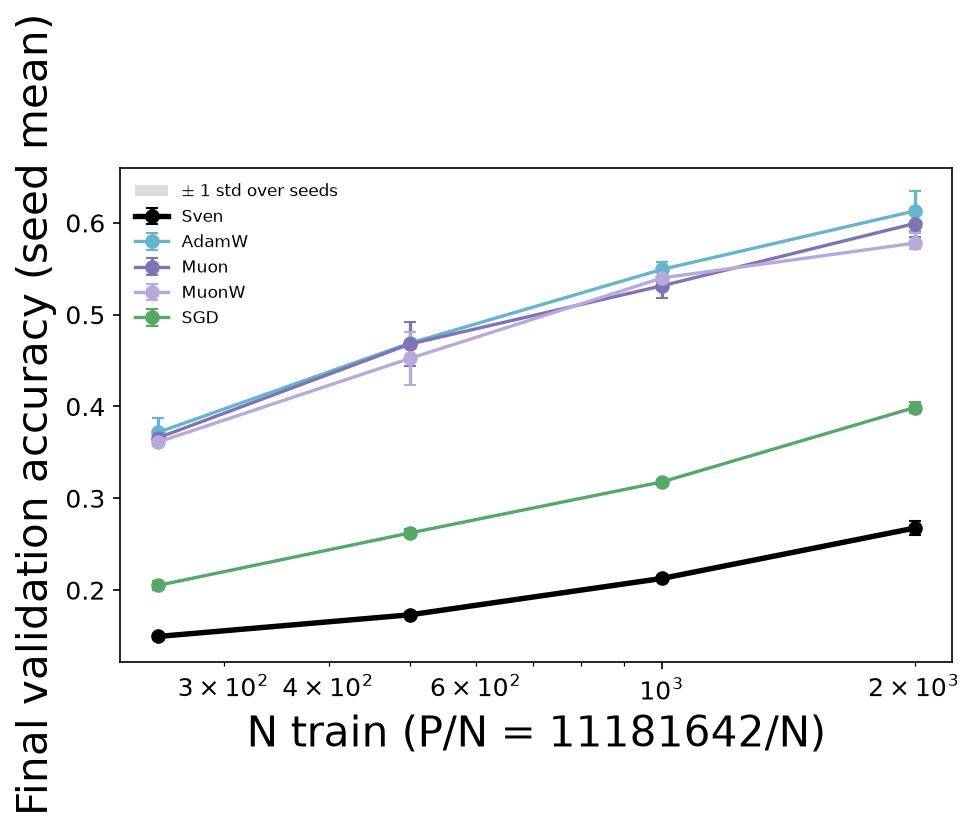

In [3]:
if df is not None:
    # Best CONFIG per (optimizer, N) by seed-mean final val loss; error bars = seed spread.
    b=best_per_method(df, by='final_val_loss', extra_group=['n_data'])
    fig,ax=plt.subplots(figsize=(6.8,4.4))
    for m in method_order(b['method'].unique()):
        errorbar_seeds(ax, b[b.method==m], 'n_data', 'final_val_acc', color=sven_color(m), lw=sven_lw(m), label=m)
    ax.set_xscale('log'); ax.set_xlabel('N train (P/N = %.0f/N)'%P); ax.set_ylabel(metric_label('final_val_acc')); ax.legend(fontsize=8)
    plt.tight_layout(); plt.savefig(PLOT_DIR/'finetune_acc_vs_N.pdf',bbox_inches='tight'); plt.show()


### Table

In [4]:
if df is not None:
    b=best_per_method(df, by='final_val_loss', extra_group=['n_data'])
    for nd in sorted(b['n_data'].unique()):
        print(f'== N={nd}  (P/N={P/nd:.0f}) ==  (best config per optimizer; mean {seed_spread_label(plain=True)})')
        for _,r in b[b.n_data==nd].sort_values('final_val_loss').iterrows():
            print(f"  {method_label(r.method):18s} val_acc={fmt_pm(r,'final_val_acc','.3f')}  val_loss={fmt_pm(r,'final_val_loss','.4f')}  seeds={r.n_seeds}")


== N=250  (P/N=44727) ==  (best config per optimizer; mean ± 1 std over seeds)
  Muon               val_acc=0.366 ± 0.005  val_loss=0.8164 ± 0.0123  seeds=3
  AdamW              val_acc=0.372 ± 0.015  val_loss=0.8193 ± 0.0099  seeds=3
  MuonW              val_acc=0.361 ± 0.004  val_loss=0.8251 ± 0.0217  seeds=3
  SGD                val_acc=0.205 ± 0.004  val_loss=1.9517 ± 0.0534  seeds=3
  Sven               val_acc=0.149 ± 0.003  val_loss=4.0489 ± 0.0726  seeds=3
== N=500  (P/N=22363) ==  (best config per optimizer; mean ± 1 std over seeds)
  Muon               val_acc=0.468 ± 0.024  val_loss=0.7094 ± 0.0320  seeds=3
  AdamW              val_acc=0.469 ± 0.001  val_loss=0.7115 ± 0.0076  seeds=3
  MuonW              val_acc=0.452 ± 0.029  val_loss=0.7262 ± 0.0383  seeds=3
  SGD                val_acc=0.262 ± 0.004  val_loss=1.3222 ± 0.0222  seeds=3
  Sven               val_acc=0.173 ± 0.003  val_loss=3.3068 ± 0.0433  seeds=3
== N=1000  (P/N=11182) ==  (best config per optimizer; mean ± 